In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Tuple
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2
from torch.utils.data import DataLoader

In [ ]:
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()


DATASETS_DIR = PROJECT_ROOT / "datasets"  
DATA_DIR     = PROJECT_ROOT / "data"    
FM_STORE     = DATA_DIR / "FM_store"

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
FM_STORE.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATASETS_DIR = {DATASETS_DIR}")
print(f"FM_STORE     = {FM_STORE}")

In [ ]:
'''Аналитическое решение'''
data = pd.read_csv(DATASETS_DIR / "diamonds.csv").drop('Unnamed: 0', axis = 1)
X = np.array(data["carat"]).reshape(-1, 1)
y = np.array(data["price"])

col = np.ones((len(X), 1))
X_with_ones = np.column_stack((X, col))

handy = (np.linalg.inv(X_with_ones.T @ X_with_ones)) @ (X_with_ones.T @ y)
w_v1 = handy[0]
b_v1 = handy[1]
y_pred_handy = X_with_ones @ handy
print (f"Коэффициент = {w_v1}, свободный член = {b_v1}")

Коэффициент = 7756.4256179686145, свободный член = -2256.360580045546


In [3]:
regres = LinearRegression(fit_intercept=False).fit(X_with_ones, y)
y_pred_sk = regres.predict(X_with_ones)
w_v2 = regres.coef_[0]
b_v2 = regres.coef_[1]
print (f"Коэффициент = {w_v2}, свободный член = {b_v2}")

Коэффициент = 7756.425617968406, свободный член = -2256.3605800452624


In [4]:
'''Сравнение результатов подсчета параметра и коэффициента'''
print(np.allclose(w_v1, w_v2))

True


In [5]:
'''Подсчет MAE'''
mae_hand = mean_absolute_error(y, y_pred_handy)
mae_sklearn = mean_absolute_error(y, y_pred_sk)
print (f"MAE ручного решения = {mae_hand}, MAE sklearn = {mae_sklearn}")

MAE ручного решения = 1007.4632473570033, MAE sklearn = 1007.4632473569847


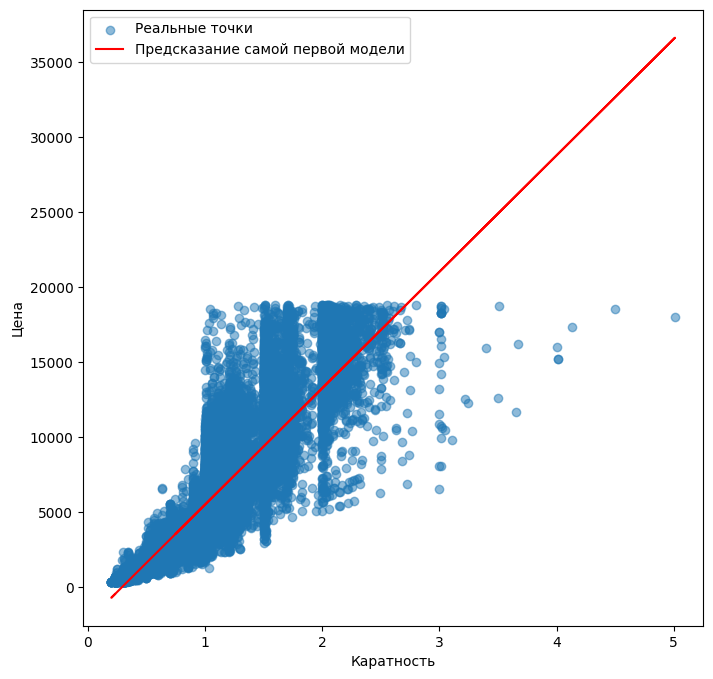

In [6]:
'''График'''
plt.figure(figsize = (8, 8))
plt.scatter(data["carat"], y, alpha = 0.5, label = "Реальные точки")
plt.plot(data["carat"], y_pred_handy, c = "red", label = "Предсказание самой первой модели")
plt.xlabel("Каратность")
plt.ylabel("Цена")
plt.legend()
plt.show()

$$
\frac{\partial J}{\partial w} = 2 \cdot (wx + b - y) \cdot x
$$

$$
\frac{\partial J}{\partial b} = 2(wx + b - y)
$$

In [7]:
'''Реализация градиентного спуска'''
class Gradient():
    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        """
        Инициализация класса.
        
        Parameters:
        -----------
        X : array-like
            Матрица признаков
        Y : array-like
            Вектор целевой переменной
        """
        if X.shape != Y.shape:
            self.x = X.flatten()        #признаки
            self.y = Y                  #Целевая переменная
        else:
            self.x = X        #признаки
            self.y = Y       #Целевая переменная
            

    def predict(self, w: np.ndarray, b: float) -> np.ndarray:
        """
        Вычисляет прогнозные значения модели.
        
        Parameters:
        -----------
        w : array-like
            Параметры модели (веса)
        b : float
            Свободный член (bias)
            
        Returns:
        --------
        prediction : array-like
            Прогнозные значения prediction = w * X + b
        """
        
        return (w * self.x + b)

    def mse(self, prediction: np.ndarray) -> float:
        """
        Вычисляет среднеквадратичную ошибку.
        
        Parameters:
        -----------
        prediction : array-like
            Предсказания модели
            
        Returns:
        --------
        mse : float
            Среднеквадратичная ошибка относительно Y
        """
        self.prediction = prediction
        mse = np.mean((self.y - self.prediction) ** 2)
        return mse

    def update(self, w: np.ndarray, b: float, a: float = 0.01) -> Tuple[np.ndarray, float]:
        """
        Обновляет параметры модели согласно формулам градиентного спуска.
        
        Parameters:
        -----------
        w : array-like
            Текущие параметры модели (веса)
        b : float
            Текущий свободный член (bias)
        a : float, default=0.01
            Learning rate (шаг обучения)
            
        Returns:
        --------
        w_new : array-like
            Обновленные параметры w
        b_new : float
            Обновленный свободный член b
        """

        self.w = w
        self.b = b
        self.a = a

        w_new = self.w - (self.a * (np.mean(2 * (self.w * self.x + self.b - self.y) * self.x)))

        b_new = self.b - (self.a * (np.mean(2 * (self.w * self.x + self.b - self.y))))

        return w_new, b_new

hand_grad = Gradient(X, y)
w = 0
b = 0
for i in range (1, 6):
    prediction = hand_grad.predict(w, b)
    mse = hand_grad.mse(prediction)
    print (f"На {i}й итерации MSE = {mse:,.2f}; W = {w:,.2f}, B = {b:,.2f}""\n")
    w, b = hand_grad.update(w, b)

На 1й итерации MSE = 31,382,248.02; W = 0.00, B = 0.00

На 2й итерации MSE = 29,837,304.25; W = 97.62, B = 78.66

На 3й итерации MSE = 28,395,300.85; W = 192.30, B = 154.18

На 4й итерации MSE = 27,049,242.58; W = 284.14, B = 226.68

На 5й итерации MSE = 25,792,610.25; W = 373.25, B = 296.27



In [8]:
class GradientDescent(Gradient):
    """
    Класс для реализации полного алгоритма градиентного спуска.
    
    Наследуется от класса Gradient и добавляет метод optimize для автоматизации
    процесса обучения модели с адаптивным learning rate.
    """
    def optimize(self, num_iterations: int, stopping_threshold: float = 0.001, 
                 a_0: float = 0.000001, w_init: float = 0, b_init: float = 0) -> dict:
        """
        Оптимизирует параметры модели с помощью градиентного спуска.
        
        Parameters:
        -----------
        num_iterations : int
            Максимальное количество итераций обучения.
        stopping_threshold : float, default=0.001
            Порог остановки: обучение прекращается, если изменение MSE между
            итерациями меньше этого значения.
        a : float, default=0.000001
            Начальный learning rate (будет уменьшаться в ходе обучения).
        w_init : float, default=0
            Начальное значение параметра w.
        b_init : float, default=0
            Начальное значение параметра b.
            
        Returns:
        --------
        result : dict
            Словарь с ключами:
            - 'w': np.ndarray — финальные параметры w;
            - 'b': float — финальный параметр b;
            - 'mse': float — финальное значение MSE;
            - 'history': list — список значений MSE на каждой итерации;
            - 'iterations': int — количество выполненных итераций.
            
        Note:
        -----
        Learning rate уменьшается по формуле: a_t = a_0 / (1 + decay * t),
        где decay = 0.01, t — номер итерации.
        """

        res = {'w': [], 'b': 0.0, 'mse': 0.0, 'history': [], 'iterations': 0}
        a_t = a_0

        while res['iterations'] < num_iterations:
            
            prediction = self.predict(w_init, b_init)
            mse = self.mse(prediction) 
            res['history'].append(mse)
            res['iterations'] += 1
            
            if res['iterations'] > 1 and res['history'][-2] - res['history'][-1] < stopping_threshold:
                break
                
            w_init, b_init = self.update(w_init, b_init, a_t)
            a_t = a_0 / (1 + 0.01 * res['iterations'])
        
        res['w'] = w_init
        res['b'] = b_init

        res['mse'] = res['history'][-1]
        
        return res

model1 = GradientDescent(X, y)
result1 = model1.optimize(100)

model2 = GradientDescent(X, y)
result2 = model2.optimize(100, a_0 = 0.001)

model3 = GradientDescent(X, y)
result3 = model3.optimize(100, a_0 = 1)

print (f"Визуализация того, что возвращает метод: \n\n{result3}")

Визуализация того, что возвращает метод: 

{'w': np.float64(9761.740546903968), 'b': np.float64(7865.599443826474), 'mse': np.float64(140708639.60557762), 'history': [np.float64(31382248.015257694), np.float64(140708639.60557762)], 'iterations': 2}


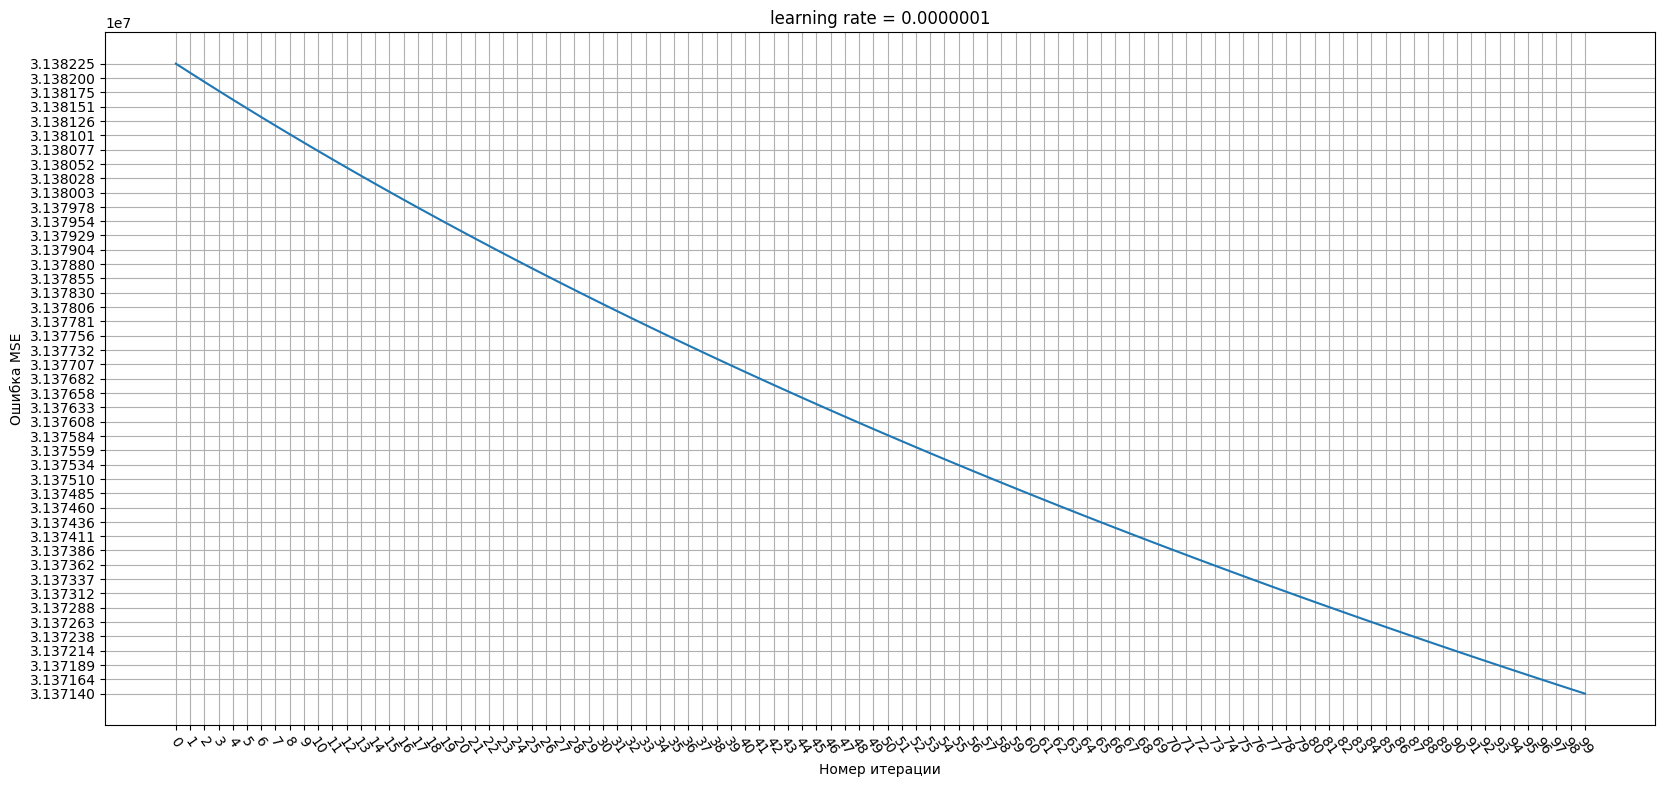

In [9]:
plt.figure(figsize = (20, 9))
plt.plot(range(result1['iterations']), result1['history'])
plt.xticks(np.arange(0, result1['iterations'], 1))
plt.yticks(np.linspace(result1['history'][-1], result1['history'][0], 45))
plt.title("learning rate = 0.0000001")
plt.xticks(rotation= - 55)
plt.xlabel('Номер итерации')
plt.ylabel('Ошибка MSE')
plt.grid(True)
plt.show()

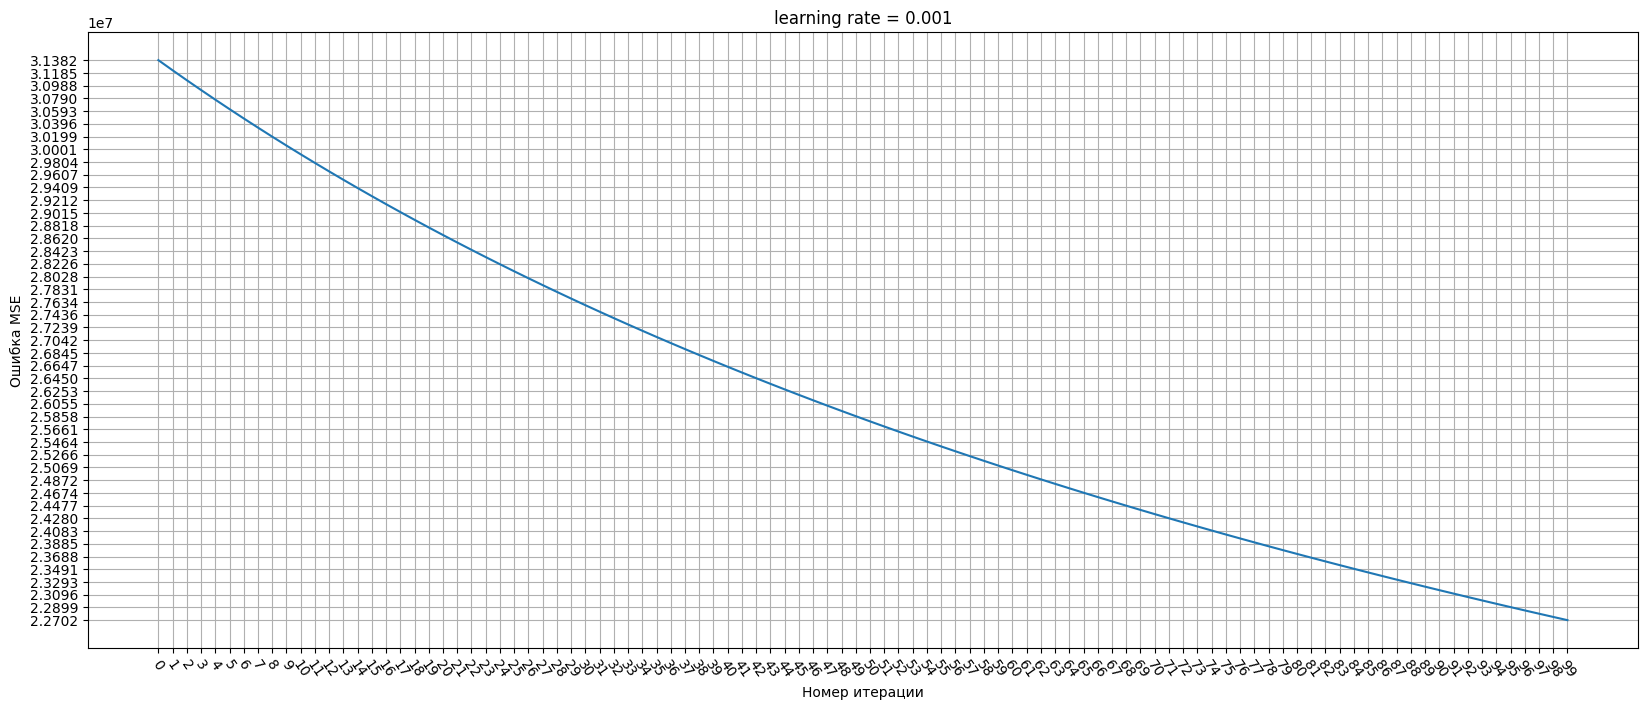

In [10]:
plt.figure(figsize = (20, 8))
plt.plot(range(result2['iterations']), result2['history'])
plt.xticks(np.arange(0, result2['iterations'], 1))
plt.yticks(np.linspace(result2['history'][-1], result2['history'][0], 45))
plt.title("learning rate = 0.001")
plt.xticks(rotation= -55)
plt.xlabel('Номер итерации')
plt.ylabel('Ошибка MSE')
plt.grid(True)
plt.show()

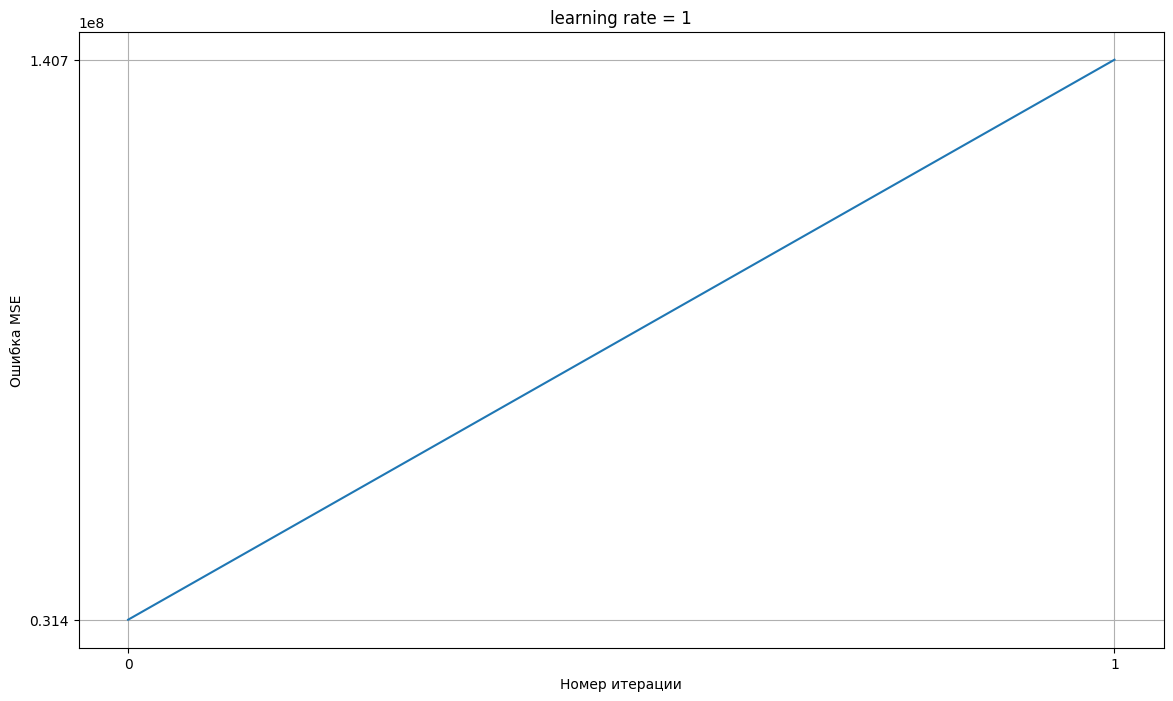

In [11]:
plt.figure(figsize = (14, 8))
plt.plot(range(result3['iterations']), result3['history'])
plt.xticks(np.arange(0, result3['iterations'], 1))
plt.yticks(np.linspace(result3['history'][-1], result3['history'][0], len(result3['history'])))
plt.title("learning rate = 1")
plt.xlabel('Номер итерации')
plt.ylabel('Ошибка MSE')
plt.grid(True)
plt.show()

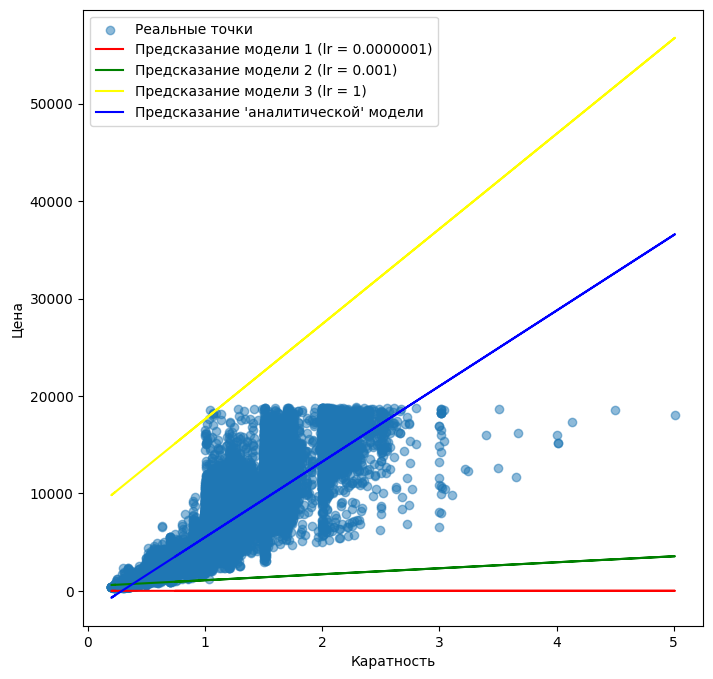

In [12]:
'''График со всеми решениями: финальные линии для разных lr и начальное решение'''
y_pred1 = X_with_ones @ (result1["w"], result1["b"])
y_pred2 = X_with_ones @ (result2["w"], result2["b"])
y_pred3 = X_with_ones @ (result3["w"], result3["b"])

plt.figure(figsize = (8, 8))
plt.scatter(data["carat"], y, alpha = 0.5, label = "Реальные точки")
plt.plot(data["carat"], y_pred1, c = "red", label = "Предсказание модели 1 (lr = 0.0000001)")
plt.plot(data["carat"], y_pred2, c = "green", label = "Предсказание модели 2 (lr = 0.001)")
plt.plot(data["carat"], y_pred3, c = "yellow", label = "Предсказание модели 3 (lr = 1)")
plt.plot(data["carat"], y_pred_handy, c = "blue", label = "Предсказание 'аналитической' модели")
plt.xlabel("Каратность")
plt.ylabel("Цена")
plt.legend()
plt.show()

In [13]:
model_for_mse = Gradient(X, y)
best_mse_hand = model_for_mse.mse(y_pred_handy)
best_mse2 = min([result1['mse'], result2['mse'], result3['mse']])
print (f"Значение MSE для лучшего результата из 4х моделей = {best_mse_hand:,.2f}")
print (f"Значение MSE для лучшего результата из 3х моделей  = {best_mse2:,.2f}")

Значение MSE для лучшего результата из 4х моделей = 2,397,955.05
Значение MSE для лучшего результата из 3х моделей  = 22,701,588.84


In [ ]:
'''Подготовка данных'''
data2 = pd.read_csv(DATASETS_DIR / "diamonds.csv").drop('Unnamed: 0', axis = 1)

X_pepe = data2.drop('price', axis = 1)
X_whole = pd.get_dummies(X_pepe, columns = ['cut', 'color', 'clarity'])
y_whole = data2['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_whole, y_whole, test_size=0.2, random_state=21)

X_train_carat = np.array(X_train[['carat']])
X_test_carat = np.array(X_test[['carat']])

scaler = StandardScaler()
train_fit_transform = scaler.fit_transform(X_train)
test_transform = scaler.transform(X_test)

scaler_for_carat = StandardScaler()
X_train_carat = scaler_for_carat.fit_transform(X_train_carat)
X_test_carat_ones = scaler_for_carat.transform(X_test_carat)

col1 = np.ones((len(X_test_carat), 1))
X_test_carat_ones = np.column_stack((X_test_carat_ones, col1))

In [15]:
'''Подсчет MAE и MSE у SGD и у решения только по каратности. Их сравнение'''
only_carat_model = GradientDescent(X_train_carat, y_train)
coefs_only_carat = only_carat_model.optimize(100, a_0 = 0.1)

SGD_reg = SGDRegressor(max_iter = 100000)
SGD_reg.fit(train_fit_transform, y_train) 

SGD_prediction = SGD_reg.predict(test_transform)
only_carat_predict = X_test_carat_ones @ (coefs_only_carat['w'], coefs_only_carat['b'])

MAE_SGD = mean_absolute_error(y_test, SGD_prediction)
MSE_SGD = mean_squared_error(y_test, SGD_prediction)

MAE_only_carat = mean_absolute_error(y_test, only_carat_predict)
MSE_only_carat = mean_squared_error(y_test, only_carat_predict)

print (f"MAE для SGD регрессора = {MAE_SGD:,.2f}")
print (f"MSE для SGD регрессора = {MSE_SGD:,.2f}")
print ('=' * 60)
print (f"MAE для предсказаний только по каратности = {MAE_only_carat:,.2f}")
print (f"MSE для предсказаний только по каратности = {MSE_only_carat:,.2f}")

MAE для SGD регрессора = 730.05
MSE для SGD регрессора = 1,245,906.76
MAE для предсказаний только по каратности = 1,003.89
MSE для предсказаний только по каратности = 2,347,993.29


In [16]:
'''Регуляризация'''


'''
Ridge регуляризация
'''
regular = Ridge(alpha = 0.01)
regular.fit(train_fit_transform, y_train)

ridge_prediction = regular.predict(test_transform)

MAE_ridge = mean_absolute_error(y_test, ridge_prediction)
MSE_ridge = mean_squared_error(y_test, ridge_prediction)

print (f"MAE с регуляризацией Ridge = {MAE_ridge}, а MSE = {MSE_ridge:,.2f}\n")


'''
Lasso регуляризация
'''
lasso = Lasso(alpha = 0.01)
lasso.fit(train_fit_transform, y_train)

lasso_prediction = lasso.predict(test_transform)

MAE_lasso = mean_absolute_error(y_test, lasso_prediction)
MSE_lasso = mean_squared_error(y_test, lasso_prediction)

print (f"MAE с регуляризацией Lasso = {MAE_lasso}, а MSE = {MSE_lasso:,.2f}\n")
print (f"MAE без регуляризации = {MAE_SGD}, а MSE = {MSE_SGD:,.2f}")

MAE с регуляризацией Ridge = 729.705307763384, а MSE = 1,225,576.56

MAE с регуляризацией Lasso = 729.7106553028068, а MSE = 1,225,574.60

MAE без регуляризации = 730.0478771428532, а MSE = 1,245,906.76


C:\Users\drm\project2\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.729603e+08, tolerance: 6.910e+07
  model = cd_fast.enet_coordinate_descent(


In [17]:
'''Логистическая регрессия'''

X, y = make_blobs(n_samples = 200, centers = 2, n_features = 2, random_state = 21)

logic = LogisticRegression(C = np.inf, solver = "lbfgs")   #В версии 1.10 вместо penalty = None используется C = np.inf

logic.fit(X, y)

w1 = logic.coef_[0][0]
w2 = logic.coef_[0][1]

b = logic.intercept_[0]

print (f"logic.coef_ = {logic.coef_}, intercept_ = {logic.intercept_}")
print (f"Точность модели = {logic.score(X, y)}")

logic.coef_ = [[ 1.60563992 -0.54271774]], intercept_ = [-0.01421595]
Точность модели = 1.0


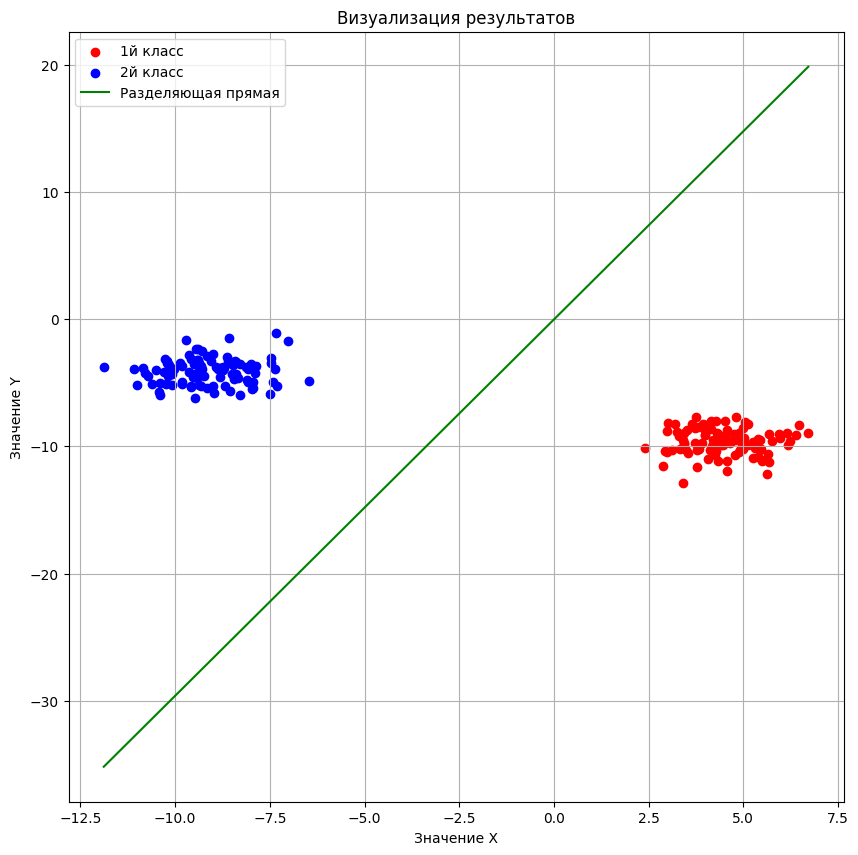

In [18]:
'''Визуализация результатов'''
start = min(X[:, 0])
stop = max(X[:, 0])
x1 = np.linspace(start, stop, 10)
x2 = [(-w1 * x - b) / w2 for x in x1]

X_positive = X[np.where(X[:, 0] > 0)]
X_negative = X[np.where(X[:, 0] < 0)]

plt.figure(figsize = (10, 10))
plt.title('Визуализация результатов')
plt.xlabel('Значение X')
plt.ylabel('Значение Y')
plt.scatter(X_positive[:, 0], X_positive[:, 1], c = 'red', label = '1й класс')
plt.scatter(X_negative[:, 0], X_negative[:, 1], c = 'blue', label = '2й класс')
plt.plot(x1, x2, label='Разделяющая прямая', c = 'green')
plt.legend()
plt.grid(True)
plt.show()

Соответствие номер класса - название класса:
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


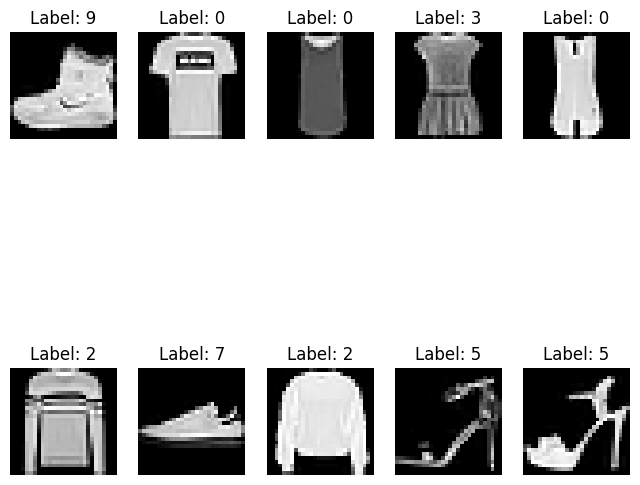

In [ ]:
'''Общая загрузка и демонстрация данных'''
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

FM_train_logis = FashionMNIST(root = FM_STORE, train = True,  download = True, transform = transform)
FM_test_logis  = FashionMNIST(root = FM_STORE, train = False, download = True, transform = transform)

print (f"Соответствие номер класса - название класса:\n{FM_train_logis.class_to_idx}")

fig, axs = plt.subplots(2, 5, figsize=(8, 8))

for i in range(2):
    for j in range(5):
        image, label = FM_train_logis[i * 5 + j] 
        image_numpy = image.numpy().squeeze()   
        axs[i, j].imshow(image_numpy, cmap='gray') 
        axs[i, j].axis('off')  
        axs[i, j].set_title(f"Label: {label}")  
 
plt.show()

In [20]:
'''Подготовка данных для логистической регрессии'''

X_test_flat = FM_test_logis.data.reshape(-1, 784).float()/255
X_train_flat = FM_train_logis.data.reshape(-1, 784).float()/255
y_test_flat = FM_test_logis.targets
y_train_flat = FM_train_logis.targets

In [21]:
LG = LogisticRegression(C = np.inf, solver = "lbfgs", max_iter=150)   #В версии 1.10 вместо penalty = None используется C = np.inf

LG.fit(X_train_flat, y_train_flat)

C:\Users\drm\project2\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 150 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=150).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",150
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [22]:
LG_prediction = LG.predict(X_test_flat)

accuracy = accuracy_score(y_test_flat, LG_prediction)
accuracy

0.8431

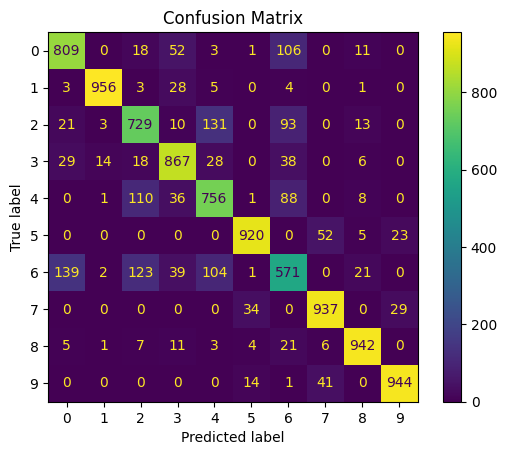

In [23]:
conf_matrix = confusion_matrix(y_test_flat, LG_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [108]:
classification_report(y_test_flat, LG_prediction, output_dict = True)

{'0': {'precision': 0.8041749502982107,
  'recall': 0.809,
  'f1-score': 0.806580259222333,
  'support': 1000.0},
 '1': {'precision': 0.9785056294779939,
  'recall': 0.956,
  'f1-score': 0.9671219018715225,
  'support': 1000.0},
 '2': {'precision': 0.7232142857142857,
  'recall': 0.729,
  'f1-score': 0.7260956175298805,
  'support': 1000.0},
 '3': {'precision': 0.8312559923298178,
  'recall': 0.867,
  'f1-score': 0.8487518355359766,
  'support': 1000.0},
 '4': {'precision': 0.7339805825242719,
  'recall': 0.756,
  'f1-score': 0.7448275862068966,
  'support': 1000.0},
 '5': {'precision': 0.9435897435897436,
  'recall': 0.92,
  'f1-score': 0.9316455696202531,
  'support': 1000.0},
 '6': {'precision': 0.6193058568329718,
  'recall': 0.571,
  'f1-score': 0.5941727367325702,
  'support': 1000.0},
 '7': {'precision': 0.9044401544401545,
  'recall': 0.937,
  'f1-score': 0.9204322200392927,
  'support': 1000.0},
 '8': {'precision': 0.9354518371400199,
  'recall': 0.942,
  'f1-score': 0.9387144

In [ ]:
'''Подготовка данных для нейросети'''
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

FM_train_nn = FashionMNIST(root = FM_STORE, train = True,  download = True, transform = transform)
FM_test_nn  = FashionMNIST(root = FM_STORE, train = False, download = True, transform = transform)

train_size = int(len(FM_train_nn) * 0.8)
val_size = len(FM_train_nn) - train_size

FM_train_data, FM_val_data = torch.utils.data.random_split(FM_train_nn, [train_size, val_size])

train_dataloader = DataLoader(FM_train_data, batch_size = 64, shuffle = True)
val_loader = DataLoader(FM_val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(FM_test_nn, batch_size = 64, shuffle = False)

FM_train_nn

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: C:\Users\drm\project2\Scripts\FM_store
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [91]:
'''Проверка модели'''
def model_testing(model, loss_criterion, dataloader):
    
    model.eval()
    
    with torch.no_grad():

        total = 0
        accuracy_sum = 0
        loss_sum = 0
        
        for batch in dataloader:
            X_batch, y_batch = batch
            
            prediction = model(X_batch)
            answer = torch.argmax(prediction, dim = 1)  #приведение ответа модели к одномерному массиву классов

            loss = loss_criterion(prediction, y_batch)
            loss_sum += loss.item() * X_batch.size(0)

            accuracy_sum += (answer == y_batch).sum().item()

            total += X_batch.size(0)

        accuracy = accuracy_sum / total
        loss = loss_sum / total
            
    return loss, accuracy
    

In [92]:
'''Нейронные сети'''
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()               #инициализируем функцию превращающую фотки в векторы
        self.fc1 = nn.Linear(784, 10)

    def forward(self, x):
        x = self.flatten(x)           #"сплющиваем" фотки в векторы перед тем, как использовать
        x = self.fc1(x)
        return x

model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.1)

In [93]:
'''Тренировка модели'''
def train_nn (model, loss_criterion, optimizer, n_epoch = 5):
    for epoch in range(n_epoch):

        loss_sum = 0
        accuracy_sum = 0
        
        model.train(True)
    
        for batch in train_dataloader:
            X_batch, y_batch = batch
            
            outputs = model(X_batch)         #ответ модели на батч картинок
            predicted = torch.argmax(outputs, dim=1)         #приводит ответ модели к одномерному массиву классов
            
            loss = loss_criterion(outputs, y_batch)     #подсчет ошибки
            loss_sum += loss.item() * X_batch.size(0)

            accuracy_sum += (predicted == y_batch).sum().item()
            
            optimizer.zero_grad()      #обнуление веса (чтобы не накапливать их, а вычислять новые)
            loss.backward()           #вычисление градиентов
            optimizer.step()          #обновление весов

        val_loss, val_accuracy = model_testing(model, loss_criterion, val_loader)
        print (f'Ошибка на валидационных данных = {val_loss:.4f}, точность = {val_accuracy:.4f}')
        
        epoch_loss = loss_sum / len(train_dataloader.dataset)
        epoch_accuracy = accuracy_sum / len(train_dataloader.dataset)
    
        print(f'Epoch [{epoch + 1}], Loss: {epoch_loss:.4f}, accuracy = {epoch_accuracy:.4f}')

train_nn(model, criterion, optimizer)

Ошибка на валидационных данных = 0.5338, точность = 0.8160
Epoch [1], Loss: 0.6489, accuracy = 0.7826
Ошибка на валидационных данных = 0.5106, точность = 0.8275
Epoch [2], Loss: 0.5031, accuracy = 0.8271
Ошибка на валидационных данных = 0.4738, точность = 0.8380
Epoch [3], Loss: 0.4712, accuracy = 0.8371
Ошибка на валидационных данных = 0.4632, точность = 0.8407
Epoch [4], Loss: 0.4548, accuracy = 0.8441
Ошибка на валидационных данных = 0.4809, точность = 0.8347
Epoch [5], Loss: 0.4439, accuracy = 0.8474


In [94]:
'''Проверка простой модели'''
loss, accuracy = model_testing(model, criterion, test_dataloader)
print (f'Test loss = {loss:.4f}, test accuracy = {accuracy:.4f}')

Test loss = 0.5017, test accuracy = 0.8294


In [101]:
'''Усложнение нейросети'''
class FlexibleNN(nn.Module):
    def __init__(self):
        super(FlexibleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return x

model_2 = FlexibleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_2.parameters(), lr = 0.01)

In [102]:
'''Тренировка второй модели'''
train_nn(model_2, criterion, optimizer)

Ошибка на валидационных данных = 0.9475, точность = 0.6705
Epoch [1], Loss: 1.5695, accuracy = 0.4939
Ошибка на валидационных данных = 0.7009, точность = 0.7512
Epoch [2], Loss: 0.7929, accuracy = 0.7079
Ошибка на валидационных данных = 0.6087, точность = 0.7877
Epoch [3], Loss: 0.6451, accuracy = 0.7717
Ошибка на валидационных данных = 0.5523, точность = 0.8081
Epoch [4], Loss: 0.5736, accuracy = 0.7990
Ошибка на валидационных данных = 0.5220, точность = 0.8184
Epoch [5], Loss: 0.5306, accuracy = 0.8146


In [103]:
'''Проверка второй модели'''
loss, accuracy = model_testing(model_2, criterion, test_dataloader)
print (f'Test loss = {loss:.4f}, test accuracy = {accuracy:.4f}')

Test loss = 0.5389, test accuracy = 0.8120


In [104]:
'''Эксперимент #1 - изменение количества эпох и learning rate'''
model_3 = FlexibleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_3.parameters(), lr = 0.08)  #lr был 0.01

train_nn(model_3, criterion, optimizer, n_epoch = 10)    #n_epoch был 5

Ошибка на валидационных данных = 0.5019, точность = 0.8224
Epoch [1], Loss: 0.7633, accuracy = 0.7305
Ошибка на валидационных данных = 0.4429, точность = 0.8392
Epoch [2], Loss: 0.4783, accuracy = 0.8285
Ошибка на валидационных данных = 0.4082, точность = 0.8558
Epoch [3], Loss: 0.4198, accuracy = 0.8485
Ошибка на валидационных данных = 0.3976, точность = 0.8597
Epoch [4], Loss: 0.3861, accuracy = 0.8576
Ошибка на валидационных данных = 0.4006, точность = 0.8605
Epoch [5], Loss: 0.3598, accuracy = 0.8687
Ошибка на валидационных данных = 0.3793, точность = 0.8619
Epoch [6], Loss: 0.3446, accuracy = 0.8722
Ошибка на валидационных данных = 0.4073, точность = 0.8560
Epoch [7], Loss: 0.3297, accuracy = 0.8792
Ошибка на валидационных данных = 0.3511, точность = 0.8722
Epoch [8], Loss: 0.3153, accuracy = 0.8844
Ошибка на валидационных данных = 0.3319, точность = 0.8808
Epoch [9], Loss: 0.3059, accuracy = 0.8865
Ошибка на валидационных данных = 0.3562, точность = 0.8719
Epoch [10], Loss: 0.294

In [105]:
'''Проверка модели с увеличенным кол-вом эпох и повышенным lr'''
loss, accuracy = model_testing(model_3, criterion, test_dataloader)
print (f'Test loss = {loss:.4f}, test accuracy = {accuracy:.4f}')

Test loss = 0.3766, test accuracy = 0.8641


In [106]:
'''Эксперимент #2 - смена оптимизатора'''
model_4 = FlexibleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_4.parameters(), lr = 0.01)  

train_nn(model_4, criterion, optimizer, n_epoch = 5)  

Ошибка на валидационных данных = 0.4355, точность = 0.8448
Epoch [1], Loss: 0.5387, accuracy = 0.8045
Ошибка на валидационных данных = 0.4443, точность = 0.8382
Epoch [2], Loss: 0.4207, accuracy = 0.8489
Ошибка на валидационных данных = 0.4204, точность = 0.8455
Epoch [3], Loss: 0.4000, accuracy = 0.8545
Ошибка на валидационных данных = 0.4093, точность = 0.8586
Epoch [4], Loss: 0.3820, accuracy = 0.8608
Ошибка на валидационных данных = 0.4095, точность = 0.8590
Epoch [5], Loss: 0.3628, accuracy = 0.8688


In [107]:
'''Проверка модели с другим оптимизатором'''
loss, accuracy = model_testing(model_4, criterion, test_dataloader)
print (f'Test loss = {loss:.4f}, test accuracy = {accuracy:.4f}')

Test loss = 0.4473, test accuracy = 0.8512
